<h1>Machine Learning - Supervised Learning</h1>

In [3]:
import piplite
await piplite.install("seaborn")

In [4]:
import piplite
await piplite.install("pandas")

In [5]:
import piplite
await piplite.install("numpy")

In [6]:
import piplite
await piplite.install("matplotlib")

In [7]:
import piplite
await piplite.install("scikit-learn")

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
# load the dataset
hr = pd.read_csv('Lab 21 House_Rent_Dataset.csv')
hr.head(3)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner


In [20]:
hr.shape

(4746, 12)

In [21]:
hr.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 296.7 KB


In [22]:
hr.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [23]:
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='str')

In [24]:
hr['Furnishing Status'].unique()

<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished']
Length: 3, dtype: str

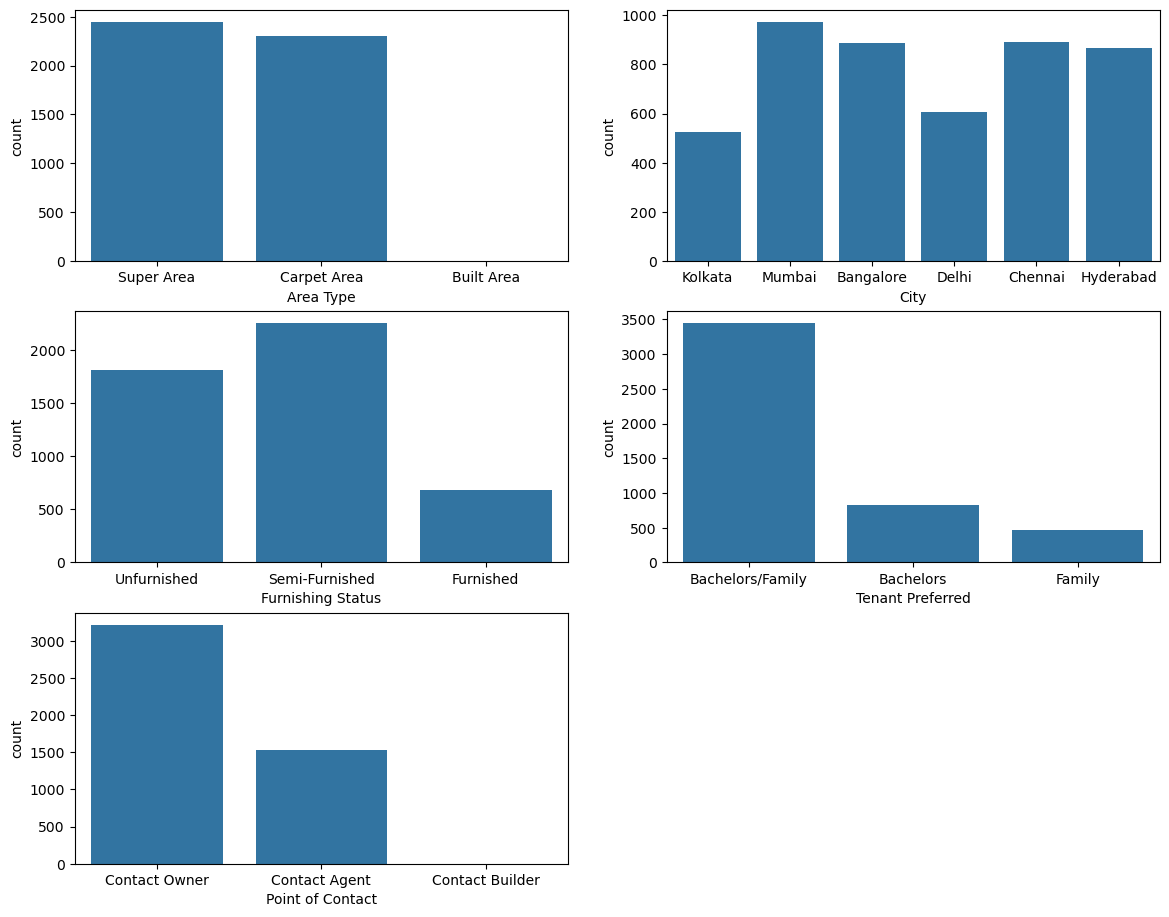

In [25]:
plt.figure(figsize=(14,15))
for i,col in enumerate(["Area Type",
                        "City",
                        "Furnishing Status",
                        "Tenant Preferred",
                        "Point of Contact"]):
    plt.subplot(4,2,i+1)
    sns.countplot(data=hr,x=col)

In [29]:
# impoerting ML libs
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import sklearn.metrics as mt
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler

In [28]:
import piplite
await piplite.install("category_encoders")

In [30]:
import category_encoders as ce

In [33]:
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='str')

In [34]:
hr = hr.drop(['Floor','Area Locality'], axis=1)
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Area Type', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='str')

In [36]:
# data splitting - 100% - 80% training set and 20% testing set
X = hr.drop(columns='Rent')
y = hr['Rent']

In [37]:
X.head()

,Posted On,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [38]:
# encoding - LOO encoder - to convert chategorical data to numerical data
encoder = ce.LeaveOneOutEncoder(return_df=True)

In [41]:
X = encoder.fit_transform(X,y) # X - independent variable, y - dependent

In [42]:
X.head()

,Posted On,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,49986.301370,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,33369.521739,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,22156.603774,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,36085.321101,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,15857.142857,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [49]:
# standardization - scaling
scalar = MinMaxScaler()
X = scalar.fit_transform(X)
# y =scalar.transform(y)

In [50]:
X

array([[0.45509995, 0.2       , 0.13642053, ..., 0.01795978, 0.11111111,
        0.00321938],
       [0.27059207, 0.2       , 0.09887359, ..., 0.01780886, 0.        ,
        0.00316481],
       [0.14608709, 0.2       , 0.12390488, ..., 0.01785413, 0.        ,
        0.00318118],
       ...,
       [0.35249127, 0.4       , 0.21777222, ..., 0.01758247, 0.22222222,
        0.99965557],
       [0.43311387, 0.4       , 0.1864831 , ..., 0.99558704, 0.11111111,
        0.99954076],
       [0.11689738, 0.2       , 0.12390488, ..., 0.58744851, 0.11111111,
        0.00319209]], shape=(4746, 9))

In [51]:
X_df = pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7,8
0,0.455100,0.2,0.136421,0.273162,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.270592,0.2,0.098874,0.273074,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.146087,0.2,0.123905,0.273100,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.300748,0.2,0.098874,0.273162,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.076140,0.2,0.105131,0.999941,0.004452,0.009593,0.587919,0.000000,0.003233


In [52]:
# train test split function
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   train_size=0.8,
                                                   random_state=42)

In [53]:
X_train.shape, X_test.shape

((3796, 9), (950, 9))

In [54]:
# train the model
lr = LinearRegression()

In [55]:
model = lr.fit(X_train, y_train)

In [56]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
# pred
y_pred = model.predict(X_test)
print(y_pred)

[ 2.58989262e+04  1.54654610e+04  6.17905654e+04  6.66646689e+04
  1.01220978e+05  4.02706177e+04  7.38381514e+04  1.29215310e+04
  1.73402759e+05  7.82877176e+03 -4.90218521e+02  5.00509399e+03
  3.52849265e+04  1.14700951e+04  2.51361186e+04  4.25546938e+04
  1.23824715e+05  1.11473223e+03  1.48993052e+04  7.56691472e+04
  5.16486720e+04 -1.14705565e+04  6.02547890e+04  2.81649822e+04
  1.45421684e+05 -1.42075173e+04 -7.27230702e+03  5.70716527e+04
 -1.79536429e+04  2.65409097e+02 -1.34446900e+04 -4.57754742e+03
 -8.49461816e+02  2.16744925e+04  3.90462306e+04  4.88433855e+04
 -4.41864050e+03 -1.52075838e+04  2.36199893e+04 -5.00451400e+03
  2.06122043e+04  1.87414428e+05  1.80389025e+04 -9.64883709e+03
  8.08389361e+04  1.21415821e+04  7.56208888e+04  1.00183996e+05
  1.98064716e+05  3.29813027e+04  1.41481235e+04  6.29444549e+04
  2.13259267e+04  1.80556093e+04  5.85690879e+04  1.43167622e+05
  3.82215007e+04  7.13896493e+04 -4.05179310e+03  2.02813645e+04
  7.16902808e+03 -8.97980

In [62]:
# Evaluate the model
mse = mt.mean_squared_error(y_test, y_pred)
mae = mt.mean_absolute_error(y_test, y_pred)
r2 = mt.r2_score(y_test, y_pred)
print(f'The mean squared error is {mse}')
print(f'The mean absolute error is {mae}')
print(f'The R Squared Score is {r2}')

The mean squared error is 1936735071.3438058
The mean absolute error is 22517.001214504366
The R Squared Score is 0.5140402091518004


In [64]:
# mse -> mean squared error -> 1/N x (Y_T - Y_P)^2
# MAE -> MEAN ABSOLUTE ERROR -> |Y_T - Y_P| x 1/N
# r2_score -> performance model -> 1 - [(y-y^)^2 / (y-y')^2]
# RMSE -> Root mse

In [68]:
# decision tree
dtr = DecisionTreeRegressor()
model_dtr = dtr.fit(X_train, y_train)
dtr_pred = model_dtr.predict(X_test)
dtr_pred

array([ 16000.,  12000.,  28000.,   8000.,  46000.,  17000.,  57000.,
         9500., 400000.,  15000.,  10000.,  12000.,  26000.,  16000.,
        15000.,   8500., 140000.,  12000.,   6000.,  60000.,  38000.,
         7500.,  23000.,  14000., 270000.,   5000.,   6000.,  16500.,
         6500.,  15000.,   5000.,  14000.,   5000.,  12000.,  25000.,
        25000.,   7500.,   6000.,  17000.,   7000.,  13000., 330000.,
        14000.,   6000.,  60000.,  14000.,  32000.,  65000., 350000.,
        15000.,  11000.,  35000.,  18000.,  12000.,  65000., 130000.,
        35000.,  40000.,   9000.,   9000.,  18000.,   5000., 130000.,
        12000.,  50000.,  20000.,  18000.,  15500.,  35000.,  30000.,
        13000.,  24000., 100000.,   7000.,  25000.,  35000.,  12000.,
        42000.,  35000.,  28000.,  14000.,  10000.,  33000.,  10000.,
        12000.,  45000.,  35000.,  18000.,  25000.,  27000., 250000.,
        35000.,  24000., 120000.,  13000.,  12000.,  11000.,   7000.,
        20000.,  240

In [69]:
mse_dtr = mt.mean_squared_error(y_test, dtr_pred)
mae_dtr = mt.mean_absolute_error(y_test, dtr_pred)
r2_dtr = mt.r2_score(y_test, dtr_pred)
print(f'The mean squared error is {mse_dtr}')
print(f'The mean absolute error is {mae_dtr}')
print(f'The R Squared Score is {r2_dtr}')

The mean squared error is 253454832.62210527
The mean absolute error is 1129.62
The R Squared Score is 0.9364038689271822


In [70]:
rfr = RandomForestRegressor(n_estimators=100)
model_rfr = rfr.fit(X_train,y_train)
rfr_pred = model_rfr.predict(X_test)

In [74]:
mse_rfr = mt.mean_squared_error(y_test, rfr_pred)
mae_rfr = mt.mean_absolute_error(y_test, rfr_pred)
r2_rfr = mt.r2_score(y_test, rfr_pred)
print(f'The mean squared error is {mse_rfr}')
print(f'The mean absolute error is {mae_rfr}')
print(f'The R Squared Score is {r2_rfr}')

The mean squared error is 316269892.2095352
The mean absolute error is 1699.637242105263
The R Squared Score is 0.9206425014222067


In [75]:
xgbr = xgb.XGBRegressor()
model_xgbr = xgbr.fit(X_train, y_train)
xgbr_pred = model_xgbr.predict(X_test)

In [76]:
mse_xgbr = mt.mean_squared_error(y_test, xgbr_pred)
mae_xgbr = mt.mean_absolute_error(y_test, xgbr_pred)
r2_xgbr = mt.r2_score(y_test, xgbr_pred)
print(f'The mean squared error is {mse_xgbr}')
print(f'The mean absolute error is {mae_xgbr}')
print(f'The R Squared Score is {r2_xgbr}')

The mean squared error is 567711488.0
The mean absolute error is 2459.9736328125
The R Squared Score is 0.8575515151023865


<h1>Machine Learning - Classification Algorithm</h1>

In [77]:
# importing libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
# load dataset
wdf = pd.read_csv('Lab 22 winequality-red.csv')

In [79]:
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [80]:
wdf.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [81]:
wdf.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [82]:
wdf.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


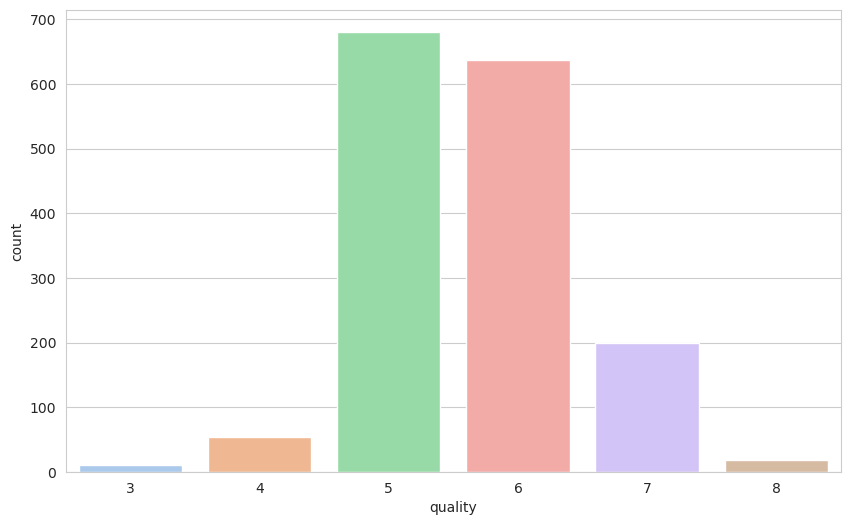

In [83]:
# visualization
sns.set_style(style='whitegrid')
print(wdf['quality'].value_counts())
fig = plt.figure(figsize=(10,6))
sns.countplot(data=wdf, x='quality', palette='pastel')
plt.show()

In [84]:
num_cols = wdf.select_dtypes(include='number')
num_cols

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<Axes: >

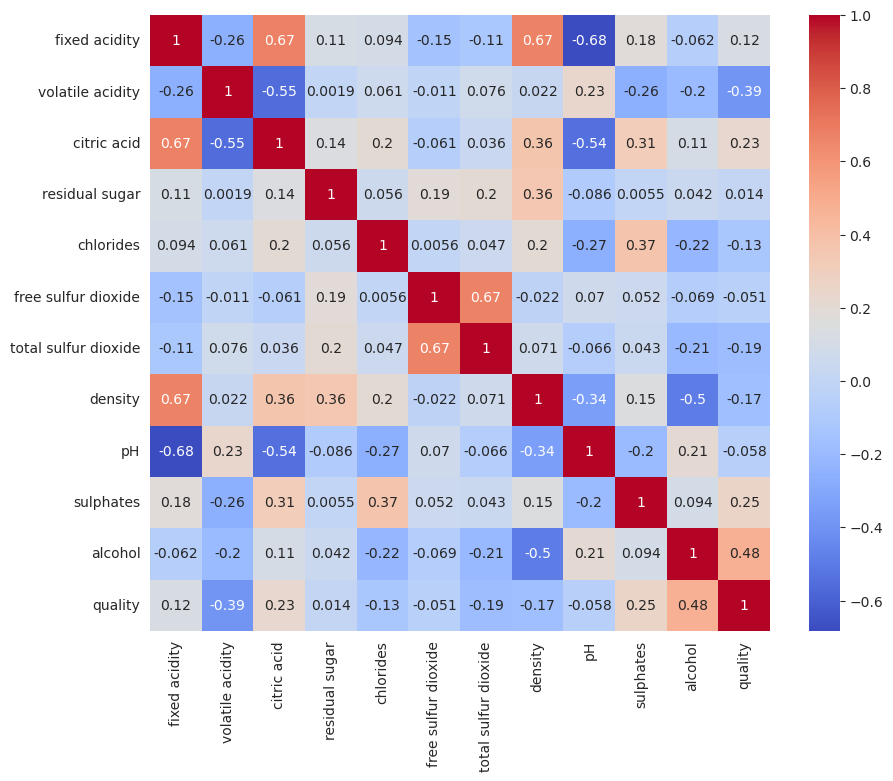

In [85]:
plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm')

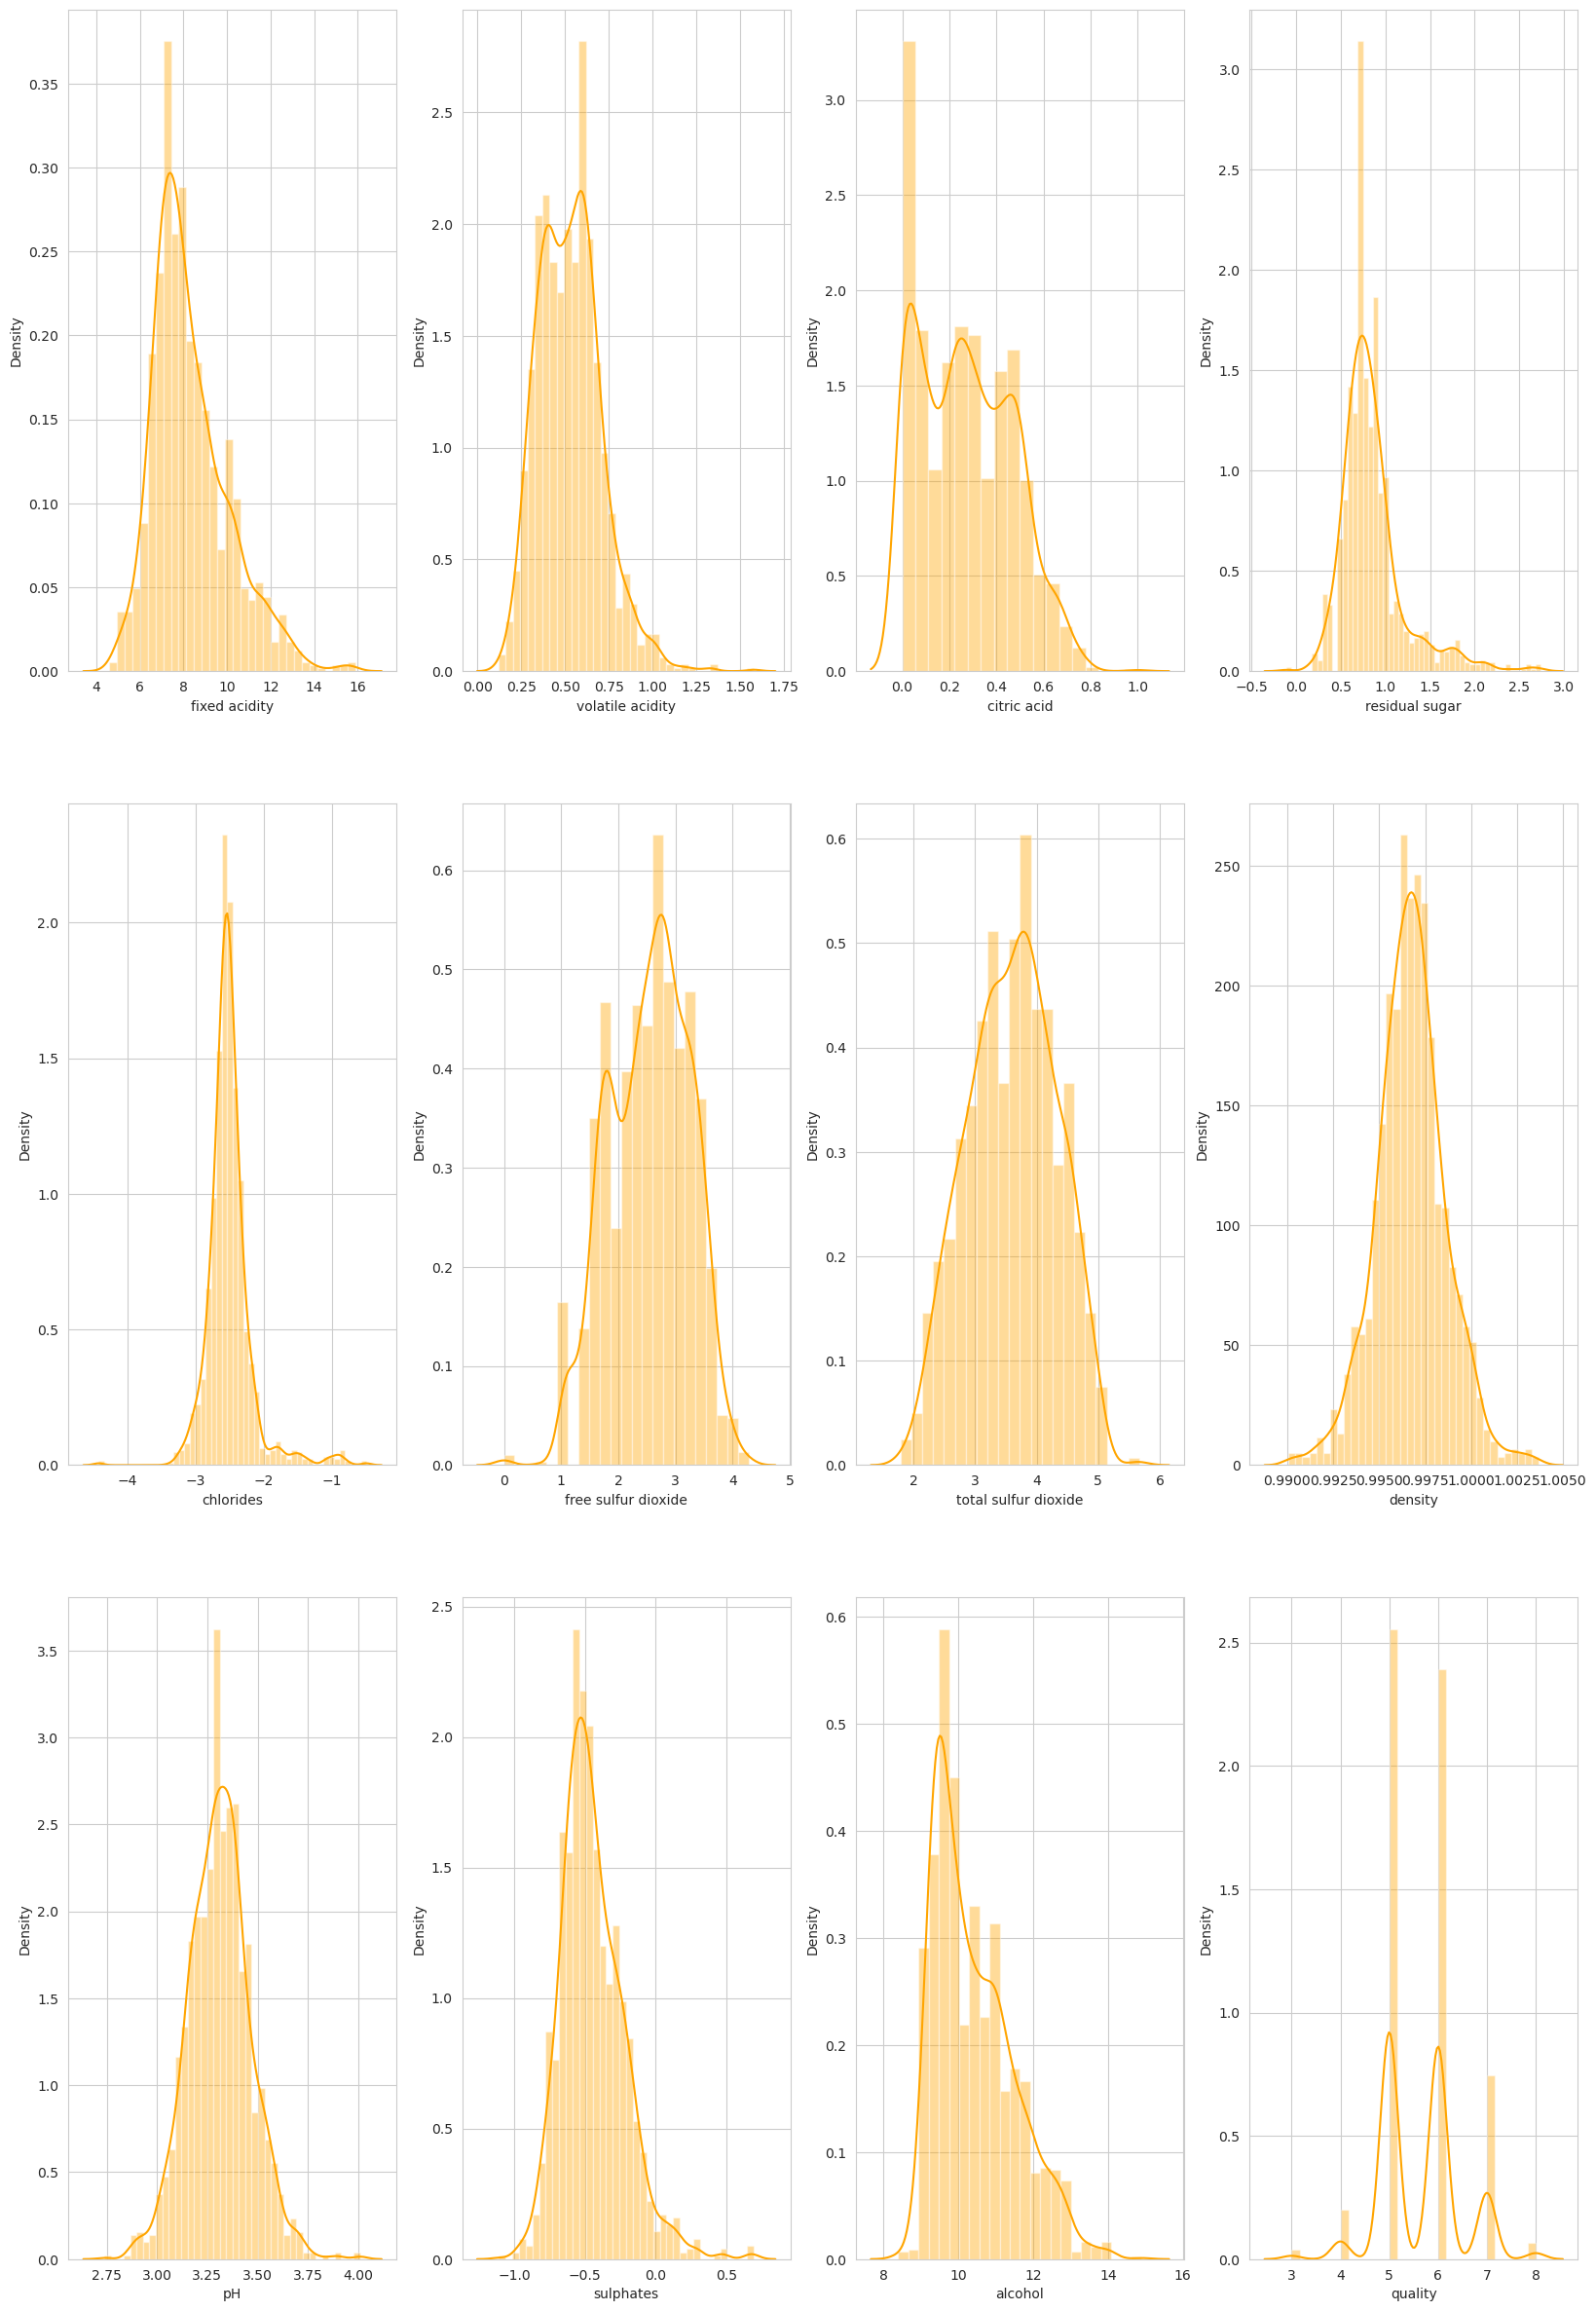

In [153]:
color = sns.color_palette('pastel')

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k=0
columns= list(wdf.columns)
for i in range(3):
    for j in range(4):
        sns.distplot(wdf[columns[k]], ax = ax1[i][j], color = 'orange')
        k = k+1
plt.show()

In [113]:
# log transformation
def log_transformation(col):
    return np.log(col)

In [114]:
wdf['residual sugar'] = wdf[['residual sugar']].apply(log_transformation, axis=1)
wdf['chlorides'] = wdf[['chlorides']].apply(log_transformation, axis=1)
wdf['free sulfur dioxide'] = wdf[['free sulfur dioxide']].apply(log_transformation, axis=1)
wdf['total sulfur dioxide'] = wdf[['total sulfur dioxide']].apply(log_transformation, axis=1)
wdf['sulphates'] = wdf[['sulphates']].apply(log_transformation, axis=1)

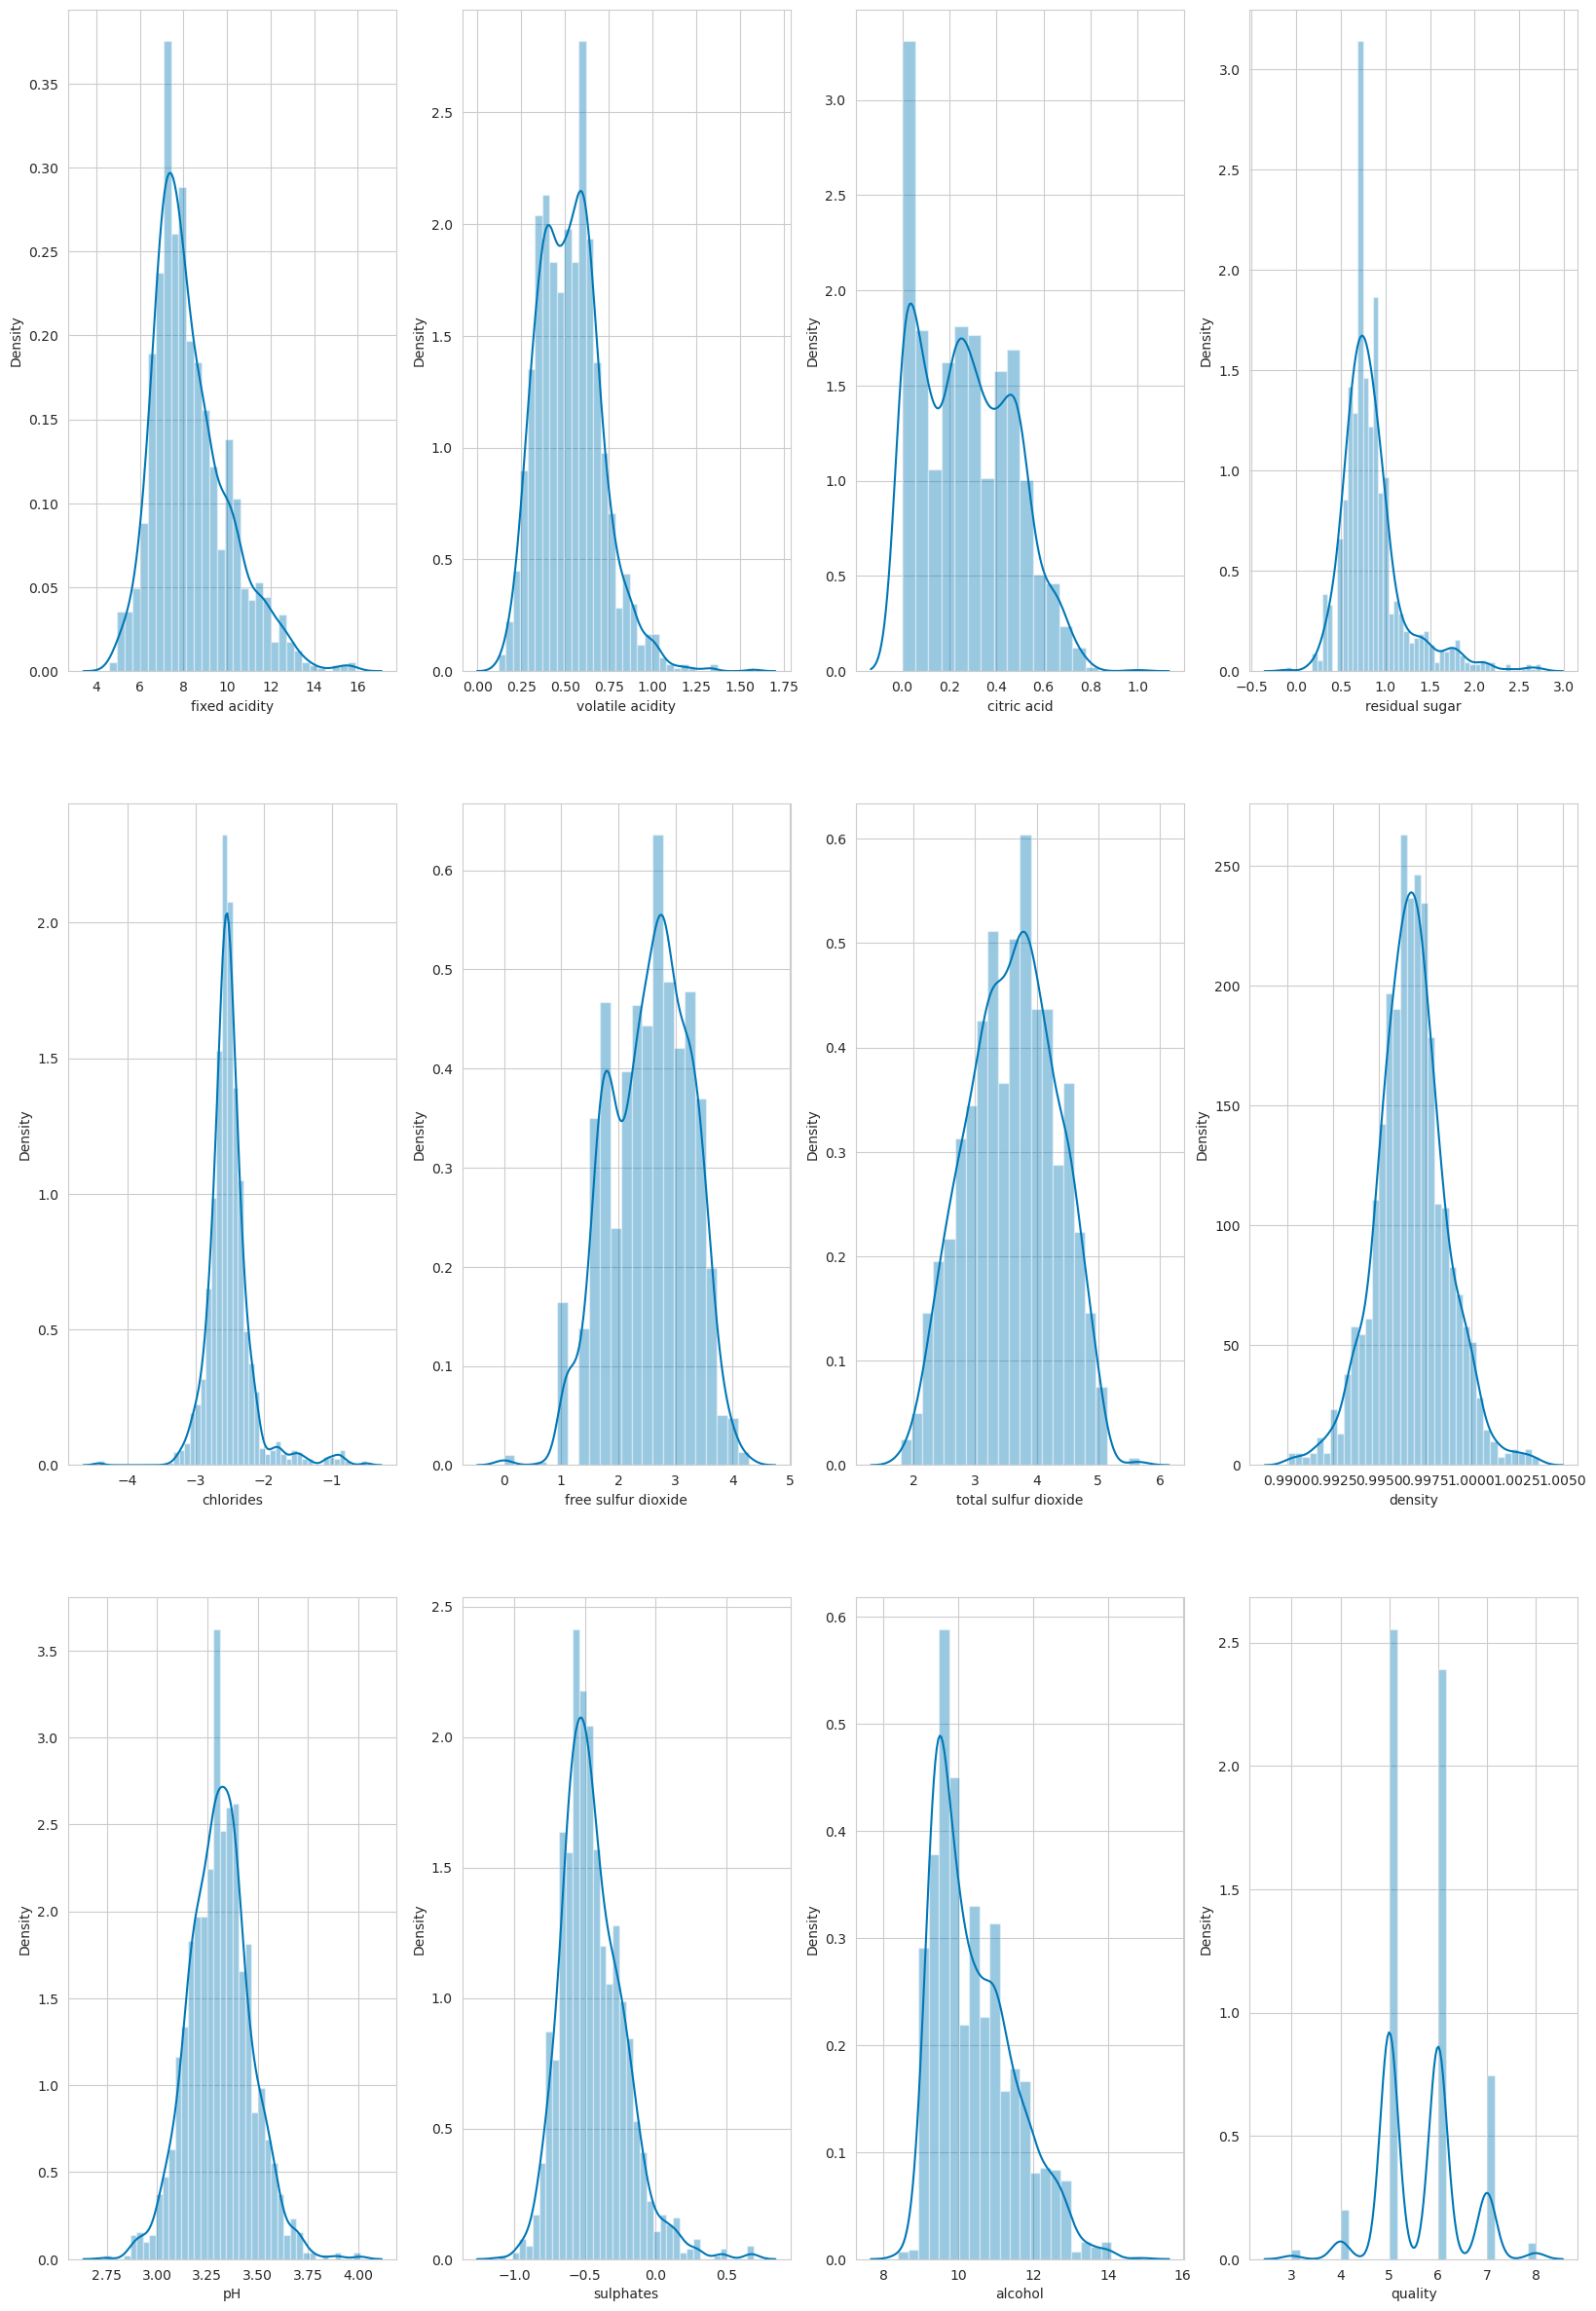

In [127]:
color = sns.color_palette('pastel')

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k=0
columns= list(wdf.columns)
for i in range(3):
    for j in range(4):
        sns.distplot(wdf[columns[k]], ax = ax1[i][j], color = '#0077B6')
        k = k+1
plt.show()

In [128]:
wdf.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.308642
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.023533
free sulfur dioxide    -0.050087
pH                     -0.057731
total sulfur dioxide   -0.170143
density                -0.174919
chlorides              -0.176140
volatile acidity       -0.390558
Name: quality, dtype: float64

In [130]:
# dataset split
x = wdf.drop(columns=['quality'])  # x - independent variable
Y = wdf['quality']                 # Y - dependent

In [131]:
Y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [132]:
import piplite
await piplite.install("imblearn")

In [137]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
x, Y = oversample.fit_resample(x.fillna(0),Y)

In [138]:
Y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [139]:
from sklearn.model_selection import train_test_split, cross_val_score

In [144]:
def classify(model, x, Y):
    x_train, x_test, Y_train, Y_test = train_test_split(x, Y, test_size=0.2, random_state=9)
    model.fit(x_train, Y_train)
    return model.score(x_test,Y_test) * 100

In [145]:
# Apply logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
LR_acc = classify(model, x, Y)
LR_acc

56.47921760391198

In [146]:
# apply RFC
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
rf_acc = classify(model_rf, x, Y)
rf_acc

88.26405867970661